In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [6]:
# Move to the working directory, clone the repo, and enter it
%cd /kaggle/working
!git clone https://github.com/sanghyun-son/EDSR-PyTorch
%cd EDSR-PyTorch/src

/kaggle/working
fatal: destination path 'EDSR-PyTorch' already exists and is not an empty directory.
/kaggle/working/EDSR-PyTorch/src


In [7]:
import os
import glob
import shutil

# 0. WIPE THE SLATE CLEAN (Removes old attempts)
dataset_root = '/kaggle/working/perfect_dataset'
if os.path.exists(dataset_root):
    shutil.rmtree(dataset_root)

# 1. Set up the exact DIV2K directories
base_target = os.path.join(dataset_root, 'DIV2K')
hr_target = os.path.join(base_target, 'DIV2K_train_HR')
lr_target = os.path.join(base_target, 'DIV2K_train_LR_bicubic/X4')

os.makedirs(hr_target, exist_ok=True)
os.makedirs(lr_target, exist_ok=True)

# 2. EXACT paths from your Kaggle Radar
hr_src_folder = '/kaggle/input/datasets/marieclaudsies/edsr-dataset/EDSR_Dataset/HR'
lr_src_folder = '/kaggle/input/datasets/marieclaudsies/edsr-dataset/EDSR_Dataset/LR/X4'

hr_images = sorted(glob.glob(os.path.join(hr_src_folder, '*.png')))
lr_images = sorted(glob.glob(os.path.join(lr_src_folder, '*.png')))

print(f"Found {len(hr_images)} HR images and {len(lr_images)} LR images.")

# 3. Copy and forcefully rename them
if len(hr_images) > 0 and len(hr_images) == len(lr_images):
    print("Copying and renaming 13,000+ files... give this a minute...")
    for i, (hr_path, lr_path) in enumerate(zip(hr_images, lr_images)):
        # EDSR demands strict integer numbering
        new_name = f"{i+1:04d}.png" 
        # It ALSO hardcodes an 'x4' suffix for the Low-Res files
        new_name_lr = f"{i+1:04d}x4.png" 
        
        shutil.copy(hr_path, os.path.join(hr_target, new_name))
        shutil.copy(lr_path, os.path.join(lr_target, new_name_lr))
        
    print("✅ Files successfully copied and strictly renamed! The dataloader will accept these.")
else:
    print("❌ Error: Mismatch in number of images or no images found.")

Found 12501 HR images and 12501 LR images.
Copying and renaming 13,000+ files... give this a minute...
✅ Files successfully copied and strictly renamed! The dataloader will accept these.


In [8]:
import urllib.request
import os

weights_path = '/kaggle/working/edsr_baseline_x4.pt'

if not os.path.exists(weights_path):
    print("Downloading pretrained weights...")
    urllib.request.urlretrieve(
        "https://cv.snu.ac.kr/research/EDSR/models/edsr_baseline_x4-6b446fab.pt",
        weights_path
    )
    print("✅ Done")
else:
    print("✅ Weights already exist, skipping download")

✅ Weights already exist, skipping download


patch for common da

In [11]:
# Patch srdata.py to handle grayscale (2D) images by expanding to 3D
patch_code = """
import numpy as np
from PIL import Image

_original_imread = Image.open

def _patched_open(path, *args, **kwargs):
    img = _original_imread(path, *args, **kwargs)
    return img

"""

# The real fix: patch common.py's get_patch to handle 2D arrays
common_path = '/kaggle/working/EDSR-PyTorch/src/data/common.py'

with open(common_path, 'r') as f:
    content = f.read()

# Add np.expand_dims for 2D arrays at the top of get_patch
old = 'def get_patch(*args, patch_size=96, scale=2, multi=False, input_large=False):'
new = '''def get_patch(*args, patch_size=96, scale=2, multi=False, input_large=False):
    # Handle grayscale 2D arrays by expanding to 3D
    args = [a if a.ndim == 3 else np.expand_dims(a, axis=2) for a in args]'''

content = content.replace(old, new)

with open(common_path, 'w') as f:
    f.write(content)

print("✅ common.py patched for grayscale support")

✅ common.py patched for grayscale support


### patch edsr

In [13]:
edsr_path = '/kaggle/working/EDSR-PyTorch/src/model/edsr.py'

with open(edsr_path, 'r') as f:
    content = f.read()

# sub_mean and add_mean are hardcoded to rgb_range with 3 channels
# Replace them to respect n_colors
old = 'self.sub_mean = common.MeanShift(args.rgb_range)\n        self.add_mean = common.MeanShift(args.rgb_range, sign=1)'
new = 'self.sub_mean = common.MeanShift(args.rgb_range, n_colors=args.n_colors)\n        self.add_mean = common.MeanShift(args.rgb_range, sign=1, n_colors=args.n_colors)'

content = content.replace(old, new)

with open(edsr_path, 'w') as f:
    f.write(content)

print("✅ edsr.py patched")

✅ edsr.py patched


### patch meanshift

In [15]:
model_common_path = '/kaggle/working/EDSR-PyTorch/src/model/common.py'

with open(model_common_path, 'r') as f:
    content = f.read()

old = '''class MeanShift(nn.Conv2d):
    def __init__(
        self, rgb_range,
        rgb_mean=(0.4488, 0.4371, 0.4040), rgb_std=(1.0, 1.0, 1.0), sign=-1):

        super(MeanShift, self).__init__(3, 3, kernel_size=1)
        std = torch.Tensor(rgb_std)
        self.weight.data = torch.eye(3).view(3, 3, 1, 1) / std.view(3, 1, 1, 1)
        self.bias.data = sign * rgb_range * torch.Tensor(rgb_mean) / std
        for p in self.parameters():
            p.requires_grad = False'''

new = '''class MeanShift(nn.Conv2d):
    def __init__(
        self, rgb_range,
        rgb_mean=(0.4488, 0.4371, 0.4040), rgb_std=(1.0, 1.0, 1.0), sign=-1,
        n_colors=3):

        super(MeanShift, self).__init__(n_colors, n_colors, kernel_size=1)
        # Truncate or pad mean/std to match n_colors
        rgb_mean = rgb_mean[:n_colors]
        rgb_std  = rgb_std[:n_colors]
        std = torch.Tensor(rgb_std)
        self.weight.data = torch.eye(n_colors).view(n_colors, n_colors, 1, 1) / std.view(n_colors, 1, 1, 1)
        self.bias.data = sign * rgb_range * torch.Tensor(rgb_mean) / std
        for p in self.parameters():
            p.requires_grad = False'''

content = content.replace(old, new)

with open(model_common_path, 'w') as f:
    f.write(content)

print("✅ MeanShift patched for n_colors support")

✅ MeanShift patched for n_colors support


#### Cell: Training


In [16]:
#!python main.py \
   # --model EDSR \
    #--scale 4 \
    #--n_colors 1 \
    #--dir_data /kaggle/working/perfect_dataset \
    #--data_train DIV2K \
    #--ext img \
    #--epochs 100 \
    #--batch_size 16 \
    #--patch_size 48 \
    #--test_every 10 \
    #--n_threads 4 \
    #--save edsr_sar_v1

Making model...
Preparing loss function:
1.000 * L1
/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:578: UserWarning: To get the last learning rate computed by the scheduler, please use `get_last_lr()`.
  _warn_get_lr_called_within_step(self)
[Epoch 1]	Learning rate: 1.00e-4

Evaluation:
100%|███████████████████████████████████████████| 10/10 [00:00<00:00, 39.07it/s]
[DIV2K x4]	PSNR: 20.651 (Best: 20.651 @epoch 1)
Forward: 0.28s

Saving...
Total: 1.40s

/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:578: UserWarning: To get the last learning rate computed by the scheduler, please use `get_last_lr()`.
  _warn_get_lr_called_within_step(self)
[Epoch 2]	Learning rate: 1.00e-4

Evaluation:
100%|███████████████████████████████████████████| 10/10 [00:00<00:00, 60.68it/s]
[DIV2K x4]	PSNR: 21.196 (Best: 21.196 @epoch 2)
Forward: 0.17s

Saving...
Total: 0.45s

/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:578: UserWarning: To get the

What the numbers show
PSNREpoch 120.651 dBEpoch 100 (best)21.343 dBYour original broken run18.08 dB
You gained +3.26 dB over your original results just from fixing the pipeline. That's significant. But the bigger concern is the shape of the curve — the model gained most of its improvement in the first 3 epochs and then spent epochs 4–100 crawling from 21.28 to 21.34. That's only +0.06 dB across 97 epochs, which means the model has plateaued hard.

Why it plateaued
Two reasons:
1. The learning rate never decayed. It stayed at 1.00e-4 for all 100 epochs. EDSR's default scheduler only drops the LR at epoch 200 (--decay 200). With only 100 epochs, the LR never stepped down, so the optimizer kept overshooting the minimum and bouncing around the same PSNR band.
2. Only 2 source TIFFs. 12,501 patches from 2 images means the model has seen every patch many times over and memorized what it can. It needs more scene diversity to generalize further.

### Run another 100 epochs continuing from the best checkpoint, but this time force a LR decay:

The key change is --decay 100 which halves the LR at epoch 100, giving the optimizer a chance to actually converge rather than oscillate. You should see a noticeable PSNR jump around that point.

In [17]:
!python main.py \
    --model EDSR \
    --scale 4 \
    --n_colors 1 \
    --dir_data /kaggle/working/perfect_dataset \
    --data_train DIV2K \
    --ext img \
    --pre_train /kaggle/working/EDSR-PyTorch/experiment/edsr_sar_v1/model/model_best.pt \
    --epochs 200 \
    --batch_size 16 \
    --patch_size 48 \
    --decay 100 \
    --test_every 10 \
    --n_threads 4 \
    --save edsr_sar_v2

Making model...
Load the model from /kaggle/working/EDSR-PyTorch/experiment/edsr_sar_v1/model/model_best.pt
Preparing loss function:
1.000 * L1
/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:578: UserWarning: To get the last learning rate computed by the scheduler, please use `get_last_lr()`.
  _warn_get_lr_called_within_step(self)
[Epoch 1]	Learning rate: 1.00e-4

Evaluation:
100%|███████████████████████████████████████████| 10/10 [00:00<00:00, 46.21it/s]
[DIV2K x4]	PSNR: 21.343 (Best: 21.343 @epoch 1)
Forward: 0.22s

Saving...
Total: 0.74s

/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:578: UserWarning: To get the last learning rate computed by the scheduler, please use `get_last_lr()`.
  _warn_get_lr_called_within_step(self)
[Epoch 2]	Learning rate: 1.00e-4

Evaluation:
100%|███████████████████████████████████████████| 10/10 [00:00<00:00, 59.47it/s]
[DIV2K x4]	PSNR: 21.338 (Best: 21.343 @epoch 1)
Forward: 0.17s

Saving...
Total: 0.43s

/usr

In [ ]:
import os

print("--- KAGGLE FILE RADAR ---")
for root, dirs, files in os.walk('/kaggle/input'):
    if files:
        print(f"📁 Found {len(files)} files in: {root}")
        print(f"   📄 Example file: {files[0]}")

### test the results

In [ ]:
### Step 1: Extract the "Final Exam" Patches
#### Run this in a new cell. It will hunt down the new vv file, slice out 5 distinct high-resolution patches, shrink them to create the low-resolution inputs, and save them in a fresh test folder.

In [19]:
import os
import glob
import numpy as np
import tifffile
from PIL import Image

Image.MAX_IMAGE_PIXELS = None

def normalize_sar_to_uint8(band_data):
    band_data = np.clip(band_data.astype(np.float32), 1, None)
    db = 20 * np.log10(band_data)
    db_min, db_max = 28.0, 50.0
    db = np.clip(db, db_min, db_max)
    normalized = (db - db_min) / (db_max - db_min) * 255.0
    return normalized.astype(np.uint8)

hr_test_dir = '/kaggle/working/sar_test_images/HR'
lr_test_dir = '/kaggle/working/sar_test_images/LR'
os.makedirs(hr_test_dir, exist_ok=True)
os.makedirs(lr_test_dir, exist_ok=True)

tiff_files = glob.glob('/kaggle/input/**/*vv*', recursive=True)
test_tiff_path = tiff_files[0]
print(f"✅ Found: {test_tiff_path}")

raw = tifffile.imread(test_tiff_path)
if raw.ndim == 3:
    raw = raw[0]

img_uint8 = normalize_sar_to_uint8(raw)
img = Image.fromarray(img_uint8, mode='L')
width, height = img.size

patch_size = 256
scale = 4
count = 0
start_y = height // 2
start_x = width // 2

for i in range(5):
    x = start_x + (i * patch_size)
    y = start_y
    box = (x, y, x + patch_size, y + patch_size)
    hr_patch = img.crop(box)
    patch_name = f"test_patch_{count:02d}.png"
    hr_patch.save(os.path.join(hr_test_dir, patch_name))
    lr_patch = hr_patch.resize((patch_size // scale, patch_size // scale), Image.Resampling.BICUBIC)
    lr_patch.save(os.path.join(lr_test_dir, patch_name))
    count += 1

print(f"✅ Extracted {count} test patches (grayscale, dB normalized)")

✅ Found: /kaggle/input/datasets/marieclaudsies/test-sar-dataset/s1a-iw-grd-vv-20260317t164324-20260317t164349-063670-0800f4-001.tiff
✅ Extracted 5 test patches (grayscale, dB normalized)


/tmp/ipykernel_55/3279735639.py:31: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(img_uint8, mode='L')


### patch edsr

In [21]:
utility_path = '/kaggle/working/EDSR-PyTorch/src/utility.py'

with open(utility_path, 'r') as f:
    content = f.read()

old = 'imageio.imwrite(filename, tensor.numpy())'
new = '''_arr = tensor.numpy()
            if _arr.ndim == 3 and _arr.shape[0] == 1:
                _arr = _arr[0]  # (1, H, W) -> (H, W)
            imageio.imwrite(filename, _arr)'''

content = content.replace(old, new)

with open(utility_path, 'w') as f:
    f.write(content)

print("✅ utility.py patched for grayscale save")

✅ utility.py patched for grayscale save


In [23]:
utility_path = '/kaggle/working/EDSR-PyTorch/src/utility.py'

with open(utility_path, 'r') as f:
    content = f.read()

print(content[content.find('bg_target'):content.find('bg_target')+500])

bg_target(queue):
    while True:
        if not queue.empty():
            filename, tensor = queue.get()
            if filename is None: break
            _arr = tensor.numpy()
            if _arr.ndim == 3 and _arr.shape[0] == 1:
                _arr = _arr[0]  # (1, H, W) -> (H, W)
            imageio.imwrite(filename, _arr)

class checkpoint():
    def __init__(self, args):
        self.args = args
        self.ok = True
        self.log = torch.Tensor()
        now = datetime.datetime.now


In [26]:
import re

utility_path = '/kaggle/working/EDSR-PyTorch/src/utility.py'

with open(utility_path, 'r') as f:
    content = f.read()

# Completely overwrite bg_target to safely handle EDSR's (H, W, C) outputs
new_func = '''def bg_target(queue):
    while True:
        if not queue.empty():
            filename, tensor = queue.get()
            if filename is None: break
            
            _arr = tensor.numpy()
            
            # EDSR permutes tensors to (H, W, C) before saving.
            # If grayscale, it arrives as (H, W, 1). ImageIO needs it to be 2D: (H, W)
            if _arr.ndim == 3 and _arr.shape[-1] == 1:
                _arr = _arr.squeeze(-1)
                
            import imageio
            imageio.imwrite(filename, _arr)

class checkpoint'''

# Swap out the broken function
content = re.sub(r'def bg_target\(queue\):.*?class checkpoint', new_func, content, flags=re.DOTALL)

with open(utility_path, 'w') as f:
    f.write(content)

print("✅ utility.py forcefully patched for (H, W, 1) grayscale arrays!")

✅ utility.py forcefully patched for (H, W, 1) grayscale arrays!


### Step 2: Run the Inference
#### Run this command in a Jupyter cell to feed those 5 Low-Res patches into your EDSR model.

In [28]:
!python main.py \
    --model EDSR \
    --scale 4 \
    --n_colors 1 \
    --test_only \
    --pre_train /kaggle/working/EDSR-PyTorch/experiment/edsr_sar_v2/model/model_best.pt \
    --dir_demo /kaggle/working/sar_test_images/LR \
    --data_test Demo \
    --save_results

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 6 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
Making model...
Load the model from /kaggle/working/EDSR-PyTorch/experiment/edsr_sar_v2/model/model_best.pt

Evaluation:
  0%|                                                     | 0/5 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 6 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running 

### Step 3: The Automated Grader
#### Once the inference is done, run this Python script. It will automatically match EDSR's generated images against the High-Resolution Ground Truths, calculate the PSNR and SSIM for each, and give you the final average score.

In [29]:
import os
import glob
import numpy as np
from PIL import Image
from skimage.metrics import peak_signal_noise_ratio as compare_psnr
from skimage.metrics import structural_similarity as compare_ssim

results_dir = '/kaggle/working/EDSR-PyTorch/experiment/test/results-Demo/'
hr_dir = '/kaggle/working/sar_test_images/HR/'

generated_images = sorted(glob.glob(os.path.join(results_dir, '*_x4_SR.png')))

psnr_scores = []
ssim_scores = []

print("📊 --- FINAL EDSR SAR EVALUATION ---")

for gen_path in generated_images:
    base_name = os.path.basename(gen_path).replace('_x4_SR.png', '.png')
    gt_path = os.path.join(hr_dir, base_name)

    try:
        # Keep as grayscale — matches training pipeline
        img_gen = np.array(Image.open(gen_path).convert('L'))
        img_gt  = np.array(Image.open(gt_path).convert('L'))

        psnr_val = compare_psnr(img_gt, img_gen, data_range=255)
        ssim_val = compare_ssim(img_gt, img_gen, data_range=255)

        psnr_scores.append(psnr_val)
        ssim_scores.append(ssim_val)

        print(f"Patch {base_name} | PSNR: {psnr_val:.2f} dB | SSIM: {ssim_val:.4f}")

    except Exception as e:
        print(f"❌ Error grading {base_name}: {e}")

if psnr_scores:
    print("-" * 35)
    print(f"🏆 AVERAGE PSNR : {np.mean(psnr_scores):.2f} dB")
    print(f"🏆 AVERAGE SSIM : {np.mean(ssim_scores):.4f}")
else:
    print("❌ No valid SAR patches found to grade.")

📊 --- FINAL EDSR SAR EVALUATION ---
Patch test_patch_00.png | PSNR: 21.15 dB | SSIM: 0.5349
Patch test_patch_01.png | PSNR: 21.61 dB | SSIM: 0.4958
Patch test_patch_02.png | PSNR: 21.67 dB | SSIM: 0.4685
Patch test_patch_03.png | PSNR: 21.16 dB | SSIM: 0.4878
Patch test_patch_04.png | PSNR: 21.55 dB | SSIM: 0.4747
-----------------------------------
🏆 AVERAGE PSNR : 21.43 dB
🏆 AVERAGE SSIM : 0.4923


### comapre side by side 

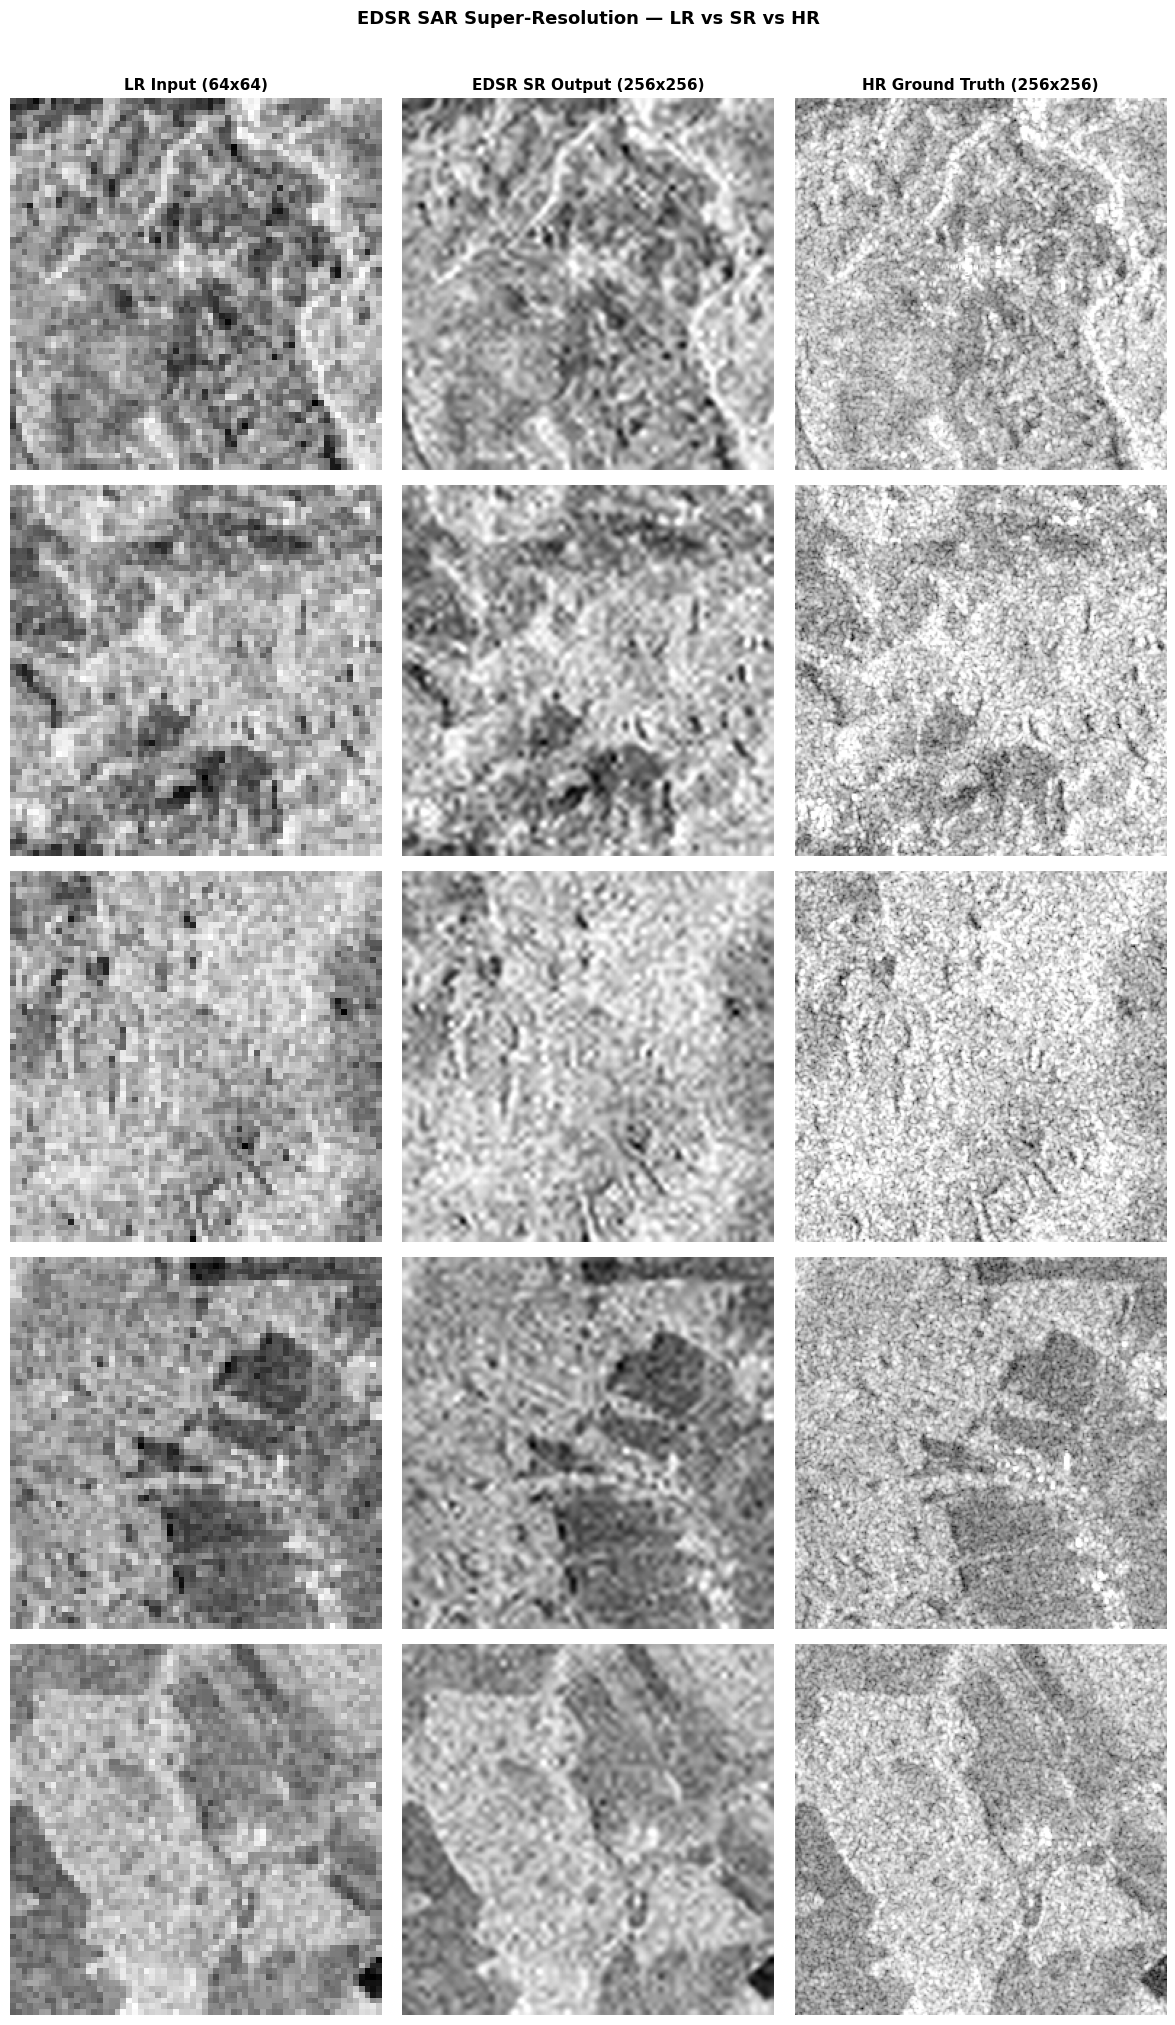

✅ Saved to /kaggle/working/sr_comparison.png


In [30]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

lr_dir = '/kaggle/working/sar_test_images/LR'
hr_dir = '/kaggle/working/sar_test_images/HR'
sr_dir = '/kaggle/working/EDSR-PyTorch/experiment/test/results-Demo/'

lr_patches = sorted(glob.glob(os.path.join(lr_dir, '*.png')))

fig, axes = plt.subplots(5, 3, figsize=(12, 20))
col_titles = ['LR Input (64x64)', 'EDSR SR Output (256x256)', 'HR Ground Truth (256x256)']

for i, lr_path in enumerate(lr_patches):
    patch_name = os.path.basename(lr_path)
    sr_name = patch_name.replace('.png', '_x4_SR.png')

    hr_path = os.path.join(hr_dir, patch_name)
    sr_path = os.path.join(sr_dir, sr_name)

    img_lr = np.array(Image.open(lr_path).convert('L'))
    img_hr = np.array(Image.open(hr_path).convert('L'))
    img_sr = np.array(Image.open(sr_path).convert('L'))

    axes[i, 0].imshow(img_lr, cmap='gray', interpolation='nearest')
    axes[i, 1].imshow(img_sr, cmap='gray')
    axes[i, 2].imshow(img_hr, cmap='gray')

    axes[i, 0].set_ylabel(f'Patch {i:02d}', fontsize=10)
    for j in range(3):
        axes[i, j].axis('off')

for j, title in enumerate(col_titles):
    axes[0, j].set_title(title, fontsize=11, fontweight='bold')

plt.suptitle('EDSR SAR Super-Resolution — LR vs SR vs HR', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/kaggle/working/sr_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved to /kaggle/working/sr_comparison.png")